# 11 · Ad exposure is self-selected — the true effect (instrumental variables · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** People who see our ads convert more — but the customers who *end up* seeing our
ads are also the ones already leaning toward us (they browse, they search, they get retargeted). So
**exposure is self-selected**, and a plain regression of sales on exposure is biased **upward**: it credits
the ad for enthusiasm that was already there. We want the *true* causal effect of an extra exposure so we
can set budgets and frequency caps that don't overspend.

### The problem in one word: endogeneity

When the treatment (ad exposure) is **correlated with the hidden drivers of the outcome** (a customer's
unobserved intent), we say exposure is **endogenous**, and no amount of controlling for what we *measured*
fixes it — the confounder (intent) is unmeasured. Notebook 05's adjustment tools are powerless here.

### The fix: an instrument

An **instrumental variable (IV)** is a third variable $Z$ that nudges the treatment *without* affecting the
outcome any other way. Here $Z$ is a randomized **encouragement** — e.g. a serving-priority lottery that
makes some customers *more likely* to be shown the ad. Because $Z$ is randomized, the slice of exposure it
drives is as-good-as-random, uncontaminated by intent. IV isolates that clean slice and reads the effect
off it. A valid instrument needs three things:

- **Relevance** — $Z$ actually moves exposure (this one we *can* test: the **first-stage F-statistic**; F <
  10 is a "weak instrument" danger sign).
- **Exclusion** — $Z$ affects sales *only through* exposure (the lottery itself sells nothing). Untestable
  from data — defended on design, and stress-tested in Step 6.
- **Exogeneity** — $Z$ is independent of the hidden confounder (guaranteed here by randomization).

### What IV recovers: a LATE

IV does **not** give the average effect over everyone. It gives the **LATE** (*Local Average Treatment
Effect*) — the effect *for the "compliers,"* the customers whose exposure the encouragement actually
changed. Always-exposed loyalists and never-exposed sceptics are silent in an IV estimate; report the scope
accordingly.

> **On real data.** IV needs a genuine instrument, which is the hard part. Good marketing instruments:
> randomized **encouragement / intent-to-treat** designs (ship the nudge to a random half), ad-auction
> or delivery randomness, or a **cost shifter** for the price-elasticity problem in notebook 03. If you can
> randomize the *encouragement* (not the exposure itself), you have a clean instrument.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 37; TRUE = 15.0

## 2 · Simulate a ground truth

The **true** exposure→sales effect is **€15**. An unobserved `engagement` drives both exposure and
sales (the confounding), so naive OLS overstates it. A randomized `encouragement` (the instrument)
nudges exposure without touching sales directly.


In [2]:
df, true_effect = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=SEED)
Fstat = est.first_stage_F(df["encouragement"], df["ad_exposure"])
fs = df.groupby("encouragement")["ad_exposure"].mean()
print(f"TRUE exposure→sales effect €{true_effect:.0f}  ·  first-stage: exposure {fs[0]:.0%}→{fs[1]:.0%} "
      f"(shift {fs[1]-fs[0]:+.0%}), F = {Fstat:.0f}")
df.head()

TRUE exposure→sales effect €15  ·  first-stage: exposure 56%→77% (shift +21%), F = 156


,encouragement,ad_exposure,sales
0,1.0,0.0,63.748992
1,1.0,1.0,64.636639
2,1.0,1.0,46.507627
3,0.0,1.0,75.599770
4,0.0,1.0,70.577754


## 3 · Identify — a valid instrument, and what IV recovers

Exposure is **endogenous** ($\text{Cov}(\text{exposure},\varepsilon)\neq 0$), so OLS is biased. A
valid instrument $Z$ (encouragement) needs three things:

- **Relevance** — $Z$ moves exposure. *Testable* (the first-stage F above; F<10 = weak).
- **Exclusion** — $Z$ affects sales *only through* exposure. *Untestable* — defended on design (a
  serving lottery sells nothing by itself). Stress-tested in step 6.
- **Exogeneity** — $Z$ independent of the confounder. Holds by randomization.

**What IV identifies — LATE (Imbens–Angrist):** under monotonicity (no defiers), IV recovers the
effect for **compliers** — customers the instrument moves — not everyone. CausalPy fits a Bayesian IV:
a joint model of (exposure, sales) with correlated errors, *estimating* the endogeneity $\rho$ rather
than assuming it away.


## 4 · Estimate — OLS, reduced form, and Bayesian IV

Three regressions tell the whole story, and seeing them side by side demystifies what IV actually does:

- **OLS** — regress sales on exposure directly. This is the **biased** number, inflated by self-selection.
- **Reduced form** — regress sales on the *instrument* (encouragement → sales). This captures only the
  effect that flows through the clean, randomized channel.
- **First stage** — regress exposure on the instrument (encouragement → exposure): how much the nudge moves
  exposure.
- **Wald / IV ratio** — reduced form ÷ first stage. The intuition: the instrument raised sales by *this*
  much and raised exposure by *that* much, so each unit of (instrument-driven) exposure is worth their
  ratio. That ratio *is* the causal effect. The **Bayesian IV** below is the same idea fit jointly with
  uncertainty (and it estimates the endogeneity $\rho$ rather than assuming it away).


In [3]:
# OLS
Xo = np.column_stack([np.ones(len(df)), df["ad_exposure"].values])
naive = np.linalg.lstsq(Xo, df["sales"].values, rcond=None)[0][1]
# reduced form and first stage → Wald/IV ratio
Zr = np.column_stack([np.ones(len(df)), df["encouragement"].values])
reduced = np.linalg.lstsq(Zr, df["sales"].values, rcond=None)[0][1]
first = np.linalg.lstsq(Zr, df["ad_exposure"].values, rcond=None)[0][1]
wald = reduced / first
# Bayesian IV — pass WEAKLY-INFORMATIVE priors. CausalPy 0.8.1 otherwise centres the
# beta priors on the 2SLS point with sigma=1, far too tight, yielding an overconfident
# interval that excludes the truth; N(0, 50) lets the data speak and gives an interval
# whose width matches the frequentist Wald SE.
result = est.iv(df, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
                instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales",
                fast=FAST, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2})
iv_post = result.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
print(f"OLS (biased)      €{naive:.1f}")
print(f"Reduced form (Z→Y) €{reduced:.1f}  ÷  first stage (Z→D) {first:.2f}  =  Wald/IV ratio €{wald:.1f}")
print(f"Bayesian IV        €{iv_post.mean():.1f}  (true €{true_effect:.0f})  90% CI [€{np.quantile(iv_post,0.05):.1f}, €{np.quantile(iv_post,0.95):.1f}]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [beta_t, beta_z, chol_cov]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


OLS (biased)      €23.7
Reduced form (Z→Y) €3.5  ÷  first stage (Z→D) 0.21  =  Wald/IV ratio €16.5
Bayesian IV        €18.1  (true €15)  90% CI [€14.8, €22.2]


## 5 · Validate — IV removes the self-selection bias

Naive OLS should sit well *above* the truth; the Wald ratio and the Bayesian IV should both **remove that
bias and land close to €15**, with the IV posterior's 90% interval **covering the truth**. The gap between
OLS and IV **is** the self-selection bias the instrument removes. (We give the Bayesian IV
weakly-informative priors so its interval reflects genuine sampling uncertainty — roughly the frequentist
Wald width — rather than the artificially tight band CausalPy's default 2SLS-centred priors would produce.)

self-selection bias removed: OLS €23.7 → IV €18.1 (true €15)


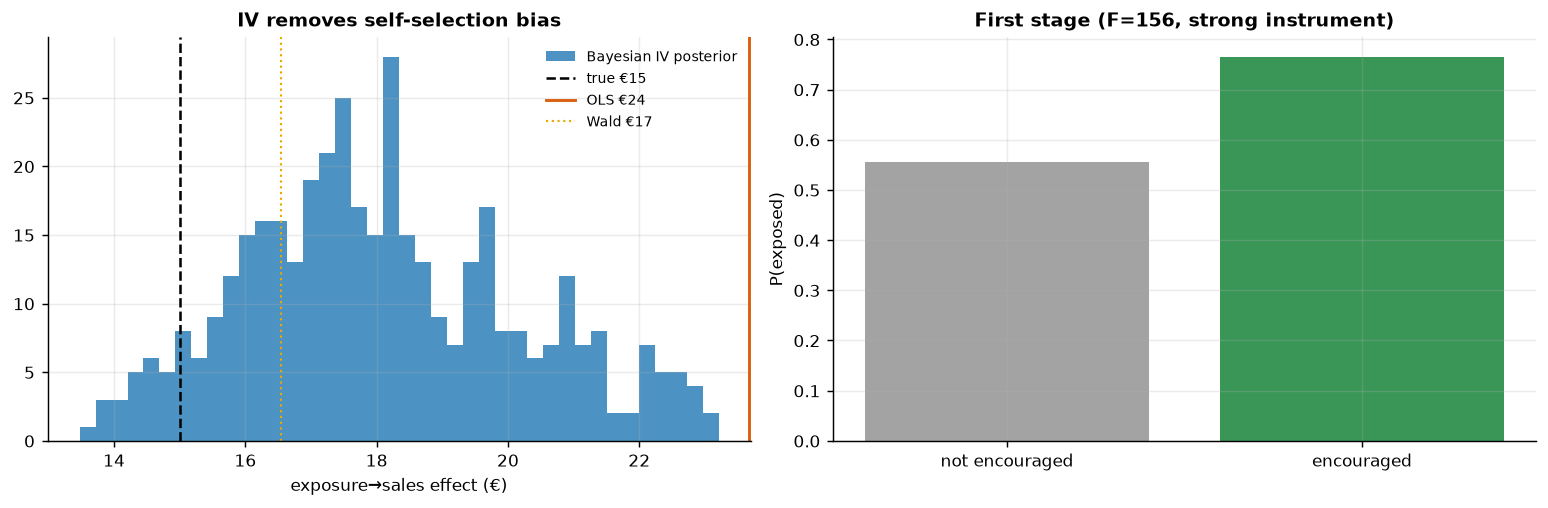

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(iv_post, bins=40, color=plots.BLUE, alpha=0.85, label="Bayesian IV posterior")
ax[0].axvline(true_effect, color="k", ls="--", lw=1.4, label=f"true €{true_effect:.0f}")
ax[0].axvline(naive, color=plots.ORANGE, lw=1.6, label=f"OLS €{naive:.0f}")
ax[0].axvline(wald, color=plots.GOLD, lw=1.2, ls=":", label=f"Wald €{wald:.0f}")
ax[0].set_xlabel("exposure→sales effect (€)"); ax[0].set_title("IV removes self-selection bias"); ax[0].legend(frameon=False, fontsize=8)
# first stage scatter
ax[1].bar(["not encouraged","encouraged"], [fs[0], fs[1]], color=[plots.GREY, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("P(exposed)"); ax[1].set_title(f"First stage (F={Fstat:.0f}, strong instrument)")
fig.tight_layout()
print(f"self-selection bias removed: OLS €{naive:.1f} → IV €{iv_post.mean():.1f} (true €{true_effect:.0f})")

**How to read this.** *Left* — three vertical lines tell the whole story: **OLS (orange) sits well above the
truth** (it credits the ad for pre-existing intent), while the **Bayesian IV posterior (blue) and the Wald
ratio (gold) both drop back down toward the true €15**. The IV point carries a little finite-sample noise (a
euro or two above 15), but its posterior — now honestly wide, thanks to weakly-informative priors —
comfortably **covers €15**; the artificially tight default-prior band would have excluded it. The horizontal
distance from the orange line to the blue posterior *is* the self-selection bias — the euros of "effect"
that were never causal. If you budgeted on OLS you'd over-spend by exactly that gap and set frequency caps
too high. *Right* — the first stage: the encouragement clearly moves exposure (a big jump in P(exposed)),
which is why the instrument is **strong** (F ≫ 10). A weak first stage here would make the whole IV
estimate unstable, so this panel is a precondition, not a footnote.

## 6 · Decide, in euros — and the exclusion-restriction stress test

Budget on the *causal* per-exposure value (IV), not the inflated OLS. But the exclusion restriction is
untestable, so we ask: **what if the encouragement had a small direct effect on sales** (say the lottery
email itself advertises)? We subtract a hypothetical direct effect $\delta$ from the reduced form and
watch the implied causal estimate move — the honest bound on how much a leak would distort the number.


Causal net €8.1/exposure  ·  P(pays) 1.00 → BUY exposure (to the complier margin)
Exclusion stress: the call survives unless the instrument's direct effect exceeds δ≈1.4 (out of a €3.5 reduced form). If you trusted OLS (€24) you'd
over-spend and set frequency caps too high.


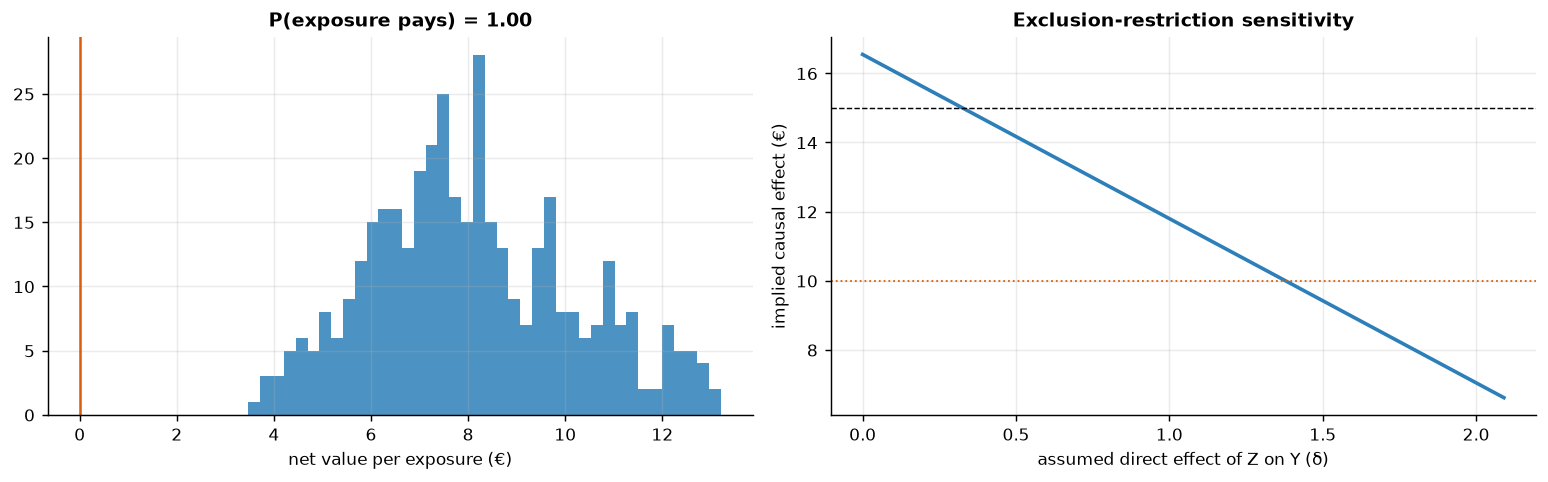

In [5]:
COST = 10.0
net = iv_post - COST; p_worth = (net > 0).mean()
# exclusion sensitivity: if Z has a direct effect delta on Y, corrected IV = (reduced - delta)/first
deltas = np.linspace(0, reduced*0.6, 20)
corrected = (reduced - deltas) / first
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85); ax[0].axvline(0, color=plots.ORANGE, lw=1.4)
ax[0].set_xlabel("net value per exposure (€)"); ax[0].set_title(f"P(exposure pays) = {p_worth:.2f}")
ax[1].plot(deltas, corrected, color=plots.BLUE, lw=2); ax[1].axhline(true_effect, color="k", ls="--", lw=0.8)
ax[1].axhline(COST, color=plots.ORANGE, ls=":", lw=1); ax[1].set_xlabel("assumed direct effect of Z on Y (δ)")
ax[1].set_ylabel("implied causal effect (€)"); ax[1].set_title("Exclusion-restriction sensitivity")
fig.tight_layout()
break_delta = deltas[np.argmax(corrected < COST)] if np.any(corrected < COST) else np.nan
print(f"Causal net €{net.mean():.1f}/exposure  ·  P(pays) {p_worth:.2f} → "
      + ("BUY exposure (to the complier margin)" if p_worth>0.9 else "hold"))
print(f"Exclusion stress: the call survives unless the instrument's direct effect exceeds "
      f"δ≈{break_delta:.1f} (out of a €{reduced:.1f} reduced form). If you trusted OLS (€{naive:.0f}) you'd\n"
      f"over-spend and set frequency caps too high.")

## 7 · Caveats

- **LATE, not ATE.** IV speaks only for **compliers** — customers the encouragement moves. Always-exposed
  loyalists and never-exposed skeptics may respond differently; report the scope.
- **Weak instruments are dangerous.** A small first-stage (low F) inflates variance and bias. We checked
  F above; a weak instrument is worse than none.
- **Exclusion is untestable.** We stress-tested it in step 6; defend it on design, not data.
- **Monotonicity (no defiers).** IV's LATE interpretation assumes no one is pushed *away* from exposure by
  encouragement — usually plausible, worth stating.
